In [276]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
df = pd.read_csv("messy_employee_dataset.csv")

## Check all the data

In [277]:
df.iloc[100:105,:]

,Employee ID,Name,Email Address,Phone No.,Gender,City,Department,Joining Date,Last Review Date,Salary (INR),Monthly Revenue,Is Active?,Performance Rating,Product Sold,Units_Sold,Discount %
100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
101,EMP9608,Meera Chopra,meera.chopra@hotmail.com,(529) 978-7729,m,NaN,Marketing,19 Feb 2024,2022-04-29,NaN,$32056.43,Yes,1,Camera,59,21%
102,EMP4625,Arjun,arjun@yahoo.com,NaN,Man,Ahmedabad,OPERATIONS,2022/08/01,2021/12/22,168273%,45886.52,False,1,Laptop,212,40%
103,EMP4257,Suresh Verma,suresh.verma@company.in,(830) 930-9671,female,Mumbai,ENGG,2020/04/09,24 Aug 2020,145676.00 INR,(37756.66),T,6,Speaker,67,2%
104,EMP5471,Divya Pandey,divya.pandey@company.in,NaN,female,Delhi,Mktg,"April 12, 2020",09-Mar-21,124385/-,47584.6,N,5,Camera,36,41%


In [278]:
df.iloc[100]

Employee ID           NaN
Name                  NaN
Email Address         NaN
Phone No.             NaN
Gender                NaN
City                  NaN
Department            NaN
Joining Date          NaN
Last Review Date      NaN
Salary (INR)          NaN
Monthly Revenue       NaN
Is Active?            NaN
Performance Rating    NaN
Product Sold          NaN
Units_Sold            NaN
Discount %            NaN
Name: 100, dtype: object

## Remove the row which is totally empty

In [279]:
df.drop(index=100,inplace=True)

In [280]:
df = df.reset_index(drop=True)

In [281]:
df.iloc[98:105,:]

,Employee ID,Name,Email Address,Phone No.,Gender,City,Department,Joining Date,Last Review Date,Salary (INR),Monthly Revenue,Is Active?,Performance Rating,Product Sold,Units_Sold,Discount %
98,NaN,Rahul Das,rahul.das@company.in,+910566418775,m,Kolkata,FINANCE,09-10-2021,11/16/2021,31651,11668.59,NaN,3,Mobile,0,37%
99,EMP8045,Meera Reddy,meera.reddy@hotmail.com,(897) 609-8731,WOMAN,Lucknow,Eng,2022-06-15,27-Feb-20,176198,26970.88,no,2,Smartwatch,309,49%
100,EMP9608,Meera Chopra,meera.chopra@hotmail.com,(529) 978-7729,m,NaN,Marketing,19 Feb 2024,2022-04-29,NaN,$32056.43,Yes,1,Camera,59,21%
101,EMP4625,Arjun,arjun@yahoo.com,NaN,Man,Ahmedabad,OPERATIONS,2022/08/01,2021/12/22,168273%,45886.52,False,1,Laptop,212,40%
102,EMP4257,Suresh Verma,suresh.verma@company.in,(830) 930-9671,female,Mumbai,ENGG,2020/04/09,24 Aug 2020,145676.00 INR,(37756.66),T,6,Speaker,67,2%
103,EMP5471,Divya Pandey,divya.pandey@company.in,NaN,female,Delhi,Mktg,"April 12, 2020",09-Mar-21,124385/-,47584.6,N,5,Camera,36,41%
104,EMP4737,aarav malhotra,aarav.malhotra@hotmail.com,5953828040,not specified,Delhi,Oprns,2023-06-03,2023/01/29,NaN,7757.31,y,4,Mobile,111,NaN


## Titlize the names for uniformity

In [282]:
df["Name"] = df["Name"].apply(lambda x:str(x).title())
df.tail()

,Employee ID,Name,Email Address,Phone No.,Gender,City,Department,Joining Date,Last Review Date,Salary (INR),Monthly Revenue,Is Active?,Performance Rating,Product Sold,Units_Sold,Discount %
646,EMP9746,Sneha Rao,sneha.rao@hotmail.com,0000000000,MALE,Jaipur,Human Resources,23-Apr-22,23-08-2021,85791,21451.29,NaN,2,Camera,389,42%
647,EMP3183,Pooja Sharma,pooja.sharma@outlook.com,20412 31905,MALE,Mumbai,Sales,19-Dec-23,"December 13, 2023",Rs.81384,18875.96,inactive,5,Smartwatch,325,9%
648,EMP4368,Pooja Singh,pooja.singh@@yahoo.com,1094416423,MALE,Chennai,Sls,06-Feb-21,2022-08-20,149940,44767.63,ACTIVE,3,Tablet,24,56%
649,EMP8215,Kavya Sharma,kavya.sharma@yahoo.com,5003342342,F,Delhi,HR,2020/02/12,15.08.2020,104972%,none,y,5,Mobile,452,50%
650,EMP5635,Arjun Mishra,arjun.mishra@outlook,+91-18961-64236,F,Kolkata,HumanResources,2024/03/21,2022-10-02,106291,none,yes,4,Speaker,289,5%


## Cleaning and fixing the emails

In [283]:
'''
diff emails: @gmail.com , @yahoo.com , @hotmail.com , @company.in , @outlook.com

problems : double @ , no .com or .in , everything in caps , 
'''

'\ndiff emails: @gmail.com , @yahoo.com , @hotmail.com , @company.in , @outlook.com\n\nproblems : double @ , no .com or .in , everything in caps , \n'

In [284]:
df["Email Address"] = (df["Email Address"]
                        .str.strip()
                        .str.lower()
                        .str.replace(
    r"(gmail|yahoo|hotmail|outlook|company)",
    r"@\1",
    regex=True
)
                        .str.replace(r'@+',"@",regex=True) )

In [285]:
df.head()

,Employee ID,Name,Email Address,Phone No.,Gender,City,Department,Joining Date,Last Review Date,Salary (INR),Monthly Revenue,Is Active?,Performance Rating,Product Sold,Units_Sold,Discount %
0,EMP6534,Pooja Shah,pooja.shah@company.in,9228777251,woman,Kolkata,H R,03-Apr-20,08/15/2023,NaN,39909.86,false,1,Laptop,268,30%
1,EMP6694,Rohit Chopra,rohit.chopra@company.in,+910450063553,man,Lucknow,Marketting,16-Jan-21,13.08.2020,124655/-,10691.49,INACTIVE,3,Tablet,237,13%
2,EMP2241,Divya Mishra,divya.mishra@yahoo.com,(532) 694-9684,Man,Jaipur,Sls,"October 31, 2023",11/26/2020,154478,36779.25,false,4,NaN,46,49%
3,EMP5407,Vikram Rao,vikram.rao@hotmail.com,(708) 213-9865,Male,Delhi,Enginering,28-Jan-24,2024/02/29,119182,₹573.76,True,5,Headphones,381,25%
4,EMP5436,"Nair, Kavya",nair.kavya@company.in,5353896298,F,Kolkata,Marketting,"November 04, 2020",08/30/2022,144974,35043.19,active,2,Headphones,147,21%


In [286]:
df.head() 

,Employee ID,Name,Email Address,Phone No.,Gender,City,Department,Joining Date,Last Review Date,Salary (INR),Monthly Revenue,Is Active?,Performance Rating,Product Sold,Units_Sold,Discount %
0,EMP6534,Pooja Shah,pooja.shah@company.in,9228777251,woman,Kolkata,H R,03-Apr-20,08/15/2023,NaN,39909.86,false,1,Laptop,268,30%
1,EMP6694,Rohit Chopra,rohit.chopra@company.in,+910450063553,man,Lucknow,Marketting,16-Jan-21,13.08.2020,124655/-,10691.49,INACTIVE,3,Tablet,237,13%
2,EMP2241,Divya Mishra,divya.mishra@yahoo.com,(532) 694-9684,Man,Jaipur,Sls,"October 31, 2023",11/26/2020,154478,36779.25,false,4,NaN,46,49%
3,EMP5407,Vikram Rao,vikram.rao@hotmail.com,(708) 213-9865,Male,Delhi,Enginering,28-Jan-24,2024/02/29,119182,₹573.76,True,5,Headphones,381,25%
4,EMP5436,"Nair, Kavya",nair.kavya@company.in,5353896298,F,Kolkata,Marketting,"November 04, 2020",08/30/2022,144974,35043.19,active,2,Headphones,147,21%


In [287]:
df["Email Address"] = (df["Email Address"]
                      .str.replace(r'@(gmail|yahoo|hotmail|outlook)$',r'@\1.com',regex=True))

In [288]:
df["Email Address"] = df["Email Address"].str.replace(r'@company$','@company.in',regex=True)

In [289]:
df.head()

,Employee ID,Name,Email Address,Phone No.,Gender,City,Department,Joining Date,Last Review Date,Salary (INR),Monthly Revenue,Is Active?,Performance Rating,Product Sold,Units_Sold,Discount %
0,EMP6534,Pooja Shah,pooja.shah@company.in,9228777251,woman,Kolkata,H R,03-Apr-20,08/15/2023,NaN,39909.86,false,1,Laptop,268,30%
1,EMP6694,Rohit Chopra,rohit.chopra@company.in,+910450063553,man,Lucknow,Marketting,16-Jan-21,13.08.2020,124655/-,10691.49,INACTIVE,3,Tablet,237,13%
2,EMP2241,Divya Mishra,divya.mishra@yahoo.com,(532) 694-9684,Man,Jaipur,Sls,"October 31, 2023",11/26/2020,154478,36779.25,false,4,NaN,46,49%
3,EMP5407,Vikram Rao,vikram.rao@hotmail.com,(708) 213-9865,Male,Delhi,Enginering,28-Jan-24,2024/02/29,119182,₹573.76,True,5,Headphones,381,25%
4,EMP5436,"Nair, Kavya",nair.kavya@company.in,5353896298,F,Kolkata,Marketting,"November 04, 2020",08/30/2022,144974,35043.19,active,2,Headphones,147,21%


## PHONE NUMBERS

In [290]:
import re
def clean_phone(val):
    if pd.isna(val) or str(val).strip() in ["", "N/A", "na", "?"]:
        return None
    
    # Strip everything except digits
    digits = re.sub(r'\D', '', str(val))
    
    # Remove leading country code 91
    if digits.startswith("91") and len(digits) == 12:
        digits = digits[2:]
    
    # Valid Indian number = exactly 10 digits
    if len(digits) == 10 and digits != "0000000000":
        return digits
    else:
        return None  # too short, too long, or fake

df["Phone No."] = df["Phone No."].apply(clean_phone)

## Gender

In [291]:
df["Gender"].unique() 

array(['woman', 'man', 'Man', 'Male', 'F', 'other', 'male', 'female',
       'MAN', 'Female', 'O', 'MALE', 'WOMAN', 'M', 'FEMALE',
       'not specified', 'Woman', 'm', 'f', 'unknown', nan, 'na', 'Other',
       'GENDER', 'NB', '?', 'Prefer not to say', 'OTHER', 'Non-binary'],
      dtype=object)

In [292]:
# male , female , unknown , other 

In [293]:
male = {"man":"Male",
 "Man":"Male",
 "M":"Male",
 "MALE":"Male",
 "MAN":"Male",
 "m":"Male",
 "male":"Male"}

In [294]:
female = {"woman":"Female", 
         "F":"Female", 
         "female":"Female", 
         "WOMAN":"Female", 
         "FEMALE":"Female", 
         "Woman":"Female",
         "f":"Female"}

In [295]:
unknown = {"not specified":"Unknown" , 
          "unknown":"Unknown", 
          "nan":"Unknown", 
          "na":"Unknown", 
          "?":"Unknown",
          "GENDER":"Unknown",
          "Prefer not to say":"Unknown"}

In [296]:
other = {"O":"Other", 
        "NB":"Other", 
        "OTHER":"Other", 
        "Non-binary":"Other", 
        "other":"Other"}

In [297]:
df["Gender"] = df["Gender"].replace(male).replace(female).replace(unknown).replace(other)

In [298]:
df["Gender"].unique()

array(['Female', 'Male', 'Other', 'Unknown', nan], dtype=object)

In [299]:
df["Gender"] = df["Gender"].fillna("Unknown")

In [300]:
df["Gender"].unique()

array(['Female', 'Male', 'Other', 'Unknown'], dtype=object)

In [301]:
df["Gender"].value_counts()

Gender
Male       302
Female     293
Unknown     35
Other       21
Name: count, dtype: int64

## CITY

In [302]:
df["City"].unique()

array(['Kolkata', 'Lucknow', 'Jaipur', 'Delhi', 'Pune', 'Hyderabad',
       'Ahmedabad', 'Bangalore', 'Chennai', 'Mumbai', nan, 'na', 'CITY'],
      dtype=object)

In [303]:
city_unknown = {"na":"Unknown","CITY":"Unknown"}

In [304]:
df["City"] = df["City"].replace(city_unknown)

In [305]:
df["City"].unique()

array(['Kolkata', 'Lucknow', 'Jaipur', 'Delhi', 'Pune', 'Hyderabad',
       'Ahmedabad', 'Bangalore', 'Chennai', 'Mumbai', nan, 'Unknown'],
      dtype=object)

In [306]:
df["City"].value_counts()

City
Delhi        76
Kolkata      74
Pune         71
Hyderabad    66
Chennai      66
Jaipur       59
Bangalore    58
Mumbai       55
Lucknow      53
Ahmedabad    44
Unknown      11
Name: count, dtype: int64

In [307]:
df["City"].isnull().sum()

np.int64(18)

In [308]:
df["Gender"] = df["Gender"].fillna("Unknown")

In [309]:
df["Gender"].isnull().sum()

np.int64(0)

## Department

In [310]:
df["Department"].unique()

array(['H R', 'Marketting', 'Sls', 'Enginering', 'Ops', 'Eng', 'H.R.',
       'Mktg', 'MKTG', 'ENGG', 'engineering', 'Engg.', 'Operations',
       'HumanResources', 'finance', 'Salez', 'OPERATIONS', 'Fin',
       'Engineering', 'operations', 'FINANCE', 'Sales', 'Finence', 'HR',
       'marketing', 'Finance', 'SALES', 'Oprns', 'hr', 'S@les',
       'Marketing', 'sales', 'Human Resources', 'DEPARTMENT'],
      dtype=object)

In [311]:
df["Department"] = df["Department"].str.lower()
df["Department"].unique()

array(['h r', 'marketting', 'sls', 'enginering', 'ops', 'eng', 'h.r.',
       'mktg', 'engg', 'engineering', 'engg.', 'operations',
       'humanresources', 'finance', 'salez', 'fin', 'sales', 'finence',
       'hr', 'marketing', 'oprns', 's@les', 'human resources',
       'department'], dtype=object)

In [312]:
# HR , Marketing , Sales , Engineering , operations , finace , 

In [313]:
dep = {"h r":"HR", 
       "marketting":"Marketing", 
      "sls":"Sales", 
      "engineering":"Engineering", 
      "ops":"Operations", 
      "eng":"Engineering",
      "h.r.":"HR", 
      "mktg":"Marketing",
      "engg":"Engineering", 
       "enginering":"Engineering", 
       "engg.":"Engineering", 
       "operations":"Operations", 
       "humanresourses":"HR", 
       "finance":"Finance", 
       "salez":"Sales",
       "fin":"Finance",
       "sales":"Sales",
       "finence":"Finance", 
       "hr":"HR",  
       "marketing":"Marketing",  
       "oprns":"Operations", 
       "s@les":"Sales",
       "human resources":"HR", 
       "humanresources":"HR"
      }

In [314]:
df["Department"] = df["Department"].replace(dep)

In [315]:
df["Department"].value_counts()

Department
Marketing      124
Operations     118
HR             107
Engineering    106
Sales          102
Finance         93
department       1
Name: count, dtype: int64

In [316]:
df["Department"] = df["Department"].str.replace("department","Unknown")

In [317]:
df["Department"].value_counts()

Department
Marketing      124
Operations     118
HR             107
Engineering    106
Sales          102
Finance         93
Unknown          1
Name: count, dtype: int64

# Joining Dates and Last Review Date

In [318]:
df["Joining Date"].head(10)

0            03-Apr-20
1            16-Jan-21
2     October 31, 2023
3            28-Jan-24
4    November 04, 2020
5           20-05-2020
6           2024-02-18
7            18-Nov-23
8           09.01.2020
9           08-12-2020
Name: Joining Date, dtype: object

In [319]:
df["Joining Date"].isnull().sum()

np.int64(7)

In [320]:
df["Joining Date"] = pd.to_datetime(df["Joining Date"],errors='coerce')

C:\Users\susha\AppData\Local\Temp\ipykernel_12516\3776633217.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Joining Date"] = pd.to_datetime(df["Joining Date"],errors='coerce')


In [321]:
df["Joining Date"].iloc[107]

NaT

In [322]:
df["Joining Date"].isnull().sum() 

np.int64(22)

In [323]:
df["Joining Date"].iloc[100:150]

100   2024-02-19
101   2022-08-01
102   2020-04-09
103   2020-04-12
104   2023-06-03
105   2022-02-11
106   2024-02-14
107          NaT
108   2022-03-20
109   2023-09-05
110   2020-11-10
111   2022-06-26
112   2023-11-08
113   2020-04-18
114   2022-10-10
115   2021-10-31
116   2021-05-08
117   2021-08-10
118   2023-02-08
119   2023-05-05
120   2020-03-23
121   2021-05-07
122   2024-03-15
123   2023-11-07
124   2023-09-15
125   2020-03-09
126   2020-05-31
127   2020-08-11
128   2022-06-24
129   2022-03-07
130   2024-01-08
131   2024-04-12
132   2021-05-29
133   2021-11-26
134   2024-03-19
135   2022-08-25
136   2020-06-22
137   2020-08-04
138   2022-02-04
139   2022-09-13
140   2021-03-20
141   2020-08-18
142   2024-04-03
143   2023-12-25
144   2021-08-10
145   2022-07-18
146   2021-02-04
147   2021-05-07
148   2020-09-05
149   2023-10-29
Name: Joining Date, dtype: datetime64[ns]

In [324]:
df["Last Review Date"].isnull().sum()

np.int64(13)

In [325]:
# df["Last Review Date"] = pd.to_datetime(df["Last Review Date"],errors='coerce')

In [326]:
# df["Last Review Date"].isnull().sum()

In [327]:
# df["Last Review Date"] 

In [328]:
# Keep original for comparison
original = df["Last Review Date"].copy()

# Convert
converted = pd.to_datetime(original, errors='coerce')

# Find rows that became NaT but were NOT originally null
failed = original[converted.isnull() & original.notnull()]

print(failed.unique()[:30])

['13.08.2020' '2024/02/29' '02-Dec-20' '03 Mar 2024' 'June 01, 2020'
 '28-Aug-21' '27 Sep 2020' '20 Mar 2024' '15-03-2024' '2020-04-26'
 '2020-12-24' '??' '22.01.2024' '21 Jul 2023' 'July 30, 2023' '2024-02-22'
 '03-09-2022' 'December 09, 2023' '15-May-24' '16-01-2024' '2023/09/13'
 '08 Apr 2020' '06-05-2024' '12-06-2020' '2022-11-11' 'June 15, 2023'
 '07 Aug 2021' '2023-08-24' '2021/04/14' '2023-12-03']


In [329]:
print(pd.__version__)

2.3.3


In [330]:
failed.shape

(547,)

In [331]:
df["Last Review Date"] = df["Last Review Date"].replace(['??', '-',"na","Last Review Date" ,'N/A', 'n/a', 'NA', 'unknown', ''], pd.NA)

In [332]:
df["Last Review Date"] = pd.to_datetime(df["Last Review Date"], format='mixed', errors='coerce')

In [333]:
df["Last Review Date"].isnull().sum()

np.int64(27)

In [334]:
df["Last Review Date"].head(50)

0    2023-08-15
1    2020-08-13
2    2020-11-26
3    2024-02-29
4    2022-08-30
5    2020-12-02
6    2024-03-03
7    2020-06-01
8    2021-08-28
9    2020-09-27
10   2024-03-20
11   2022-07-10
12   2024-03-15
13   2020-04-26
14   2021-12-01
15   2020-12-24
16          NaT
17   2022-11-20
18   2024-01-22
19   2023-07-21
20   2023-07-30
21   2024-02-22
22   2022-03-09
23   2023-12-09
24   2024-05-15
25   2024-01-16
26   2023-09-13
27   2020-04-08
28   2024-06-05
29   2020-12-06
30   2022-11-11
31   2023-06-15
32   2021-08-07
33   2023-08-24
34   2021-04-14
35   2020-06-05
36   2023-12-03
37   2023-06-24
38   2020-07-12
39   2021-08-18
40   2022-06-18
41   2021-12-16
42   2021-08-10
43   2023-09-23
44          NaT
45   2022-11-26
46   2024-02-09
47   2024-03-25
48   2023-11-02
49   2021-10-26
Name: Last Review Date, dtype: datetime64[ns]

In [335]:
df[["Last Review Date"]].sample(10)

,Last Review Date
413,2021-10-30
3,2024-02-29
49,2021-10-26
288,2021-08-15
498,2022-04-17
183,2022-06-24
42,2021-08-10
142,2021-11-27
128,2023-07-06
333,2021-03-12


## Salary

In [336]:
df["Salary (INR)"] = df["Salary (INR)"].astype(str).str.replace(r'[^0-9.]',"",regex = True)

In [337]:
df["Salary (INR)"].sample(20)

483      122735
646       85791
71       153144
594      158469
605      116871
87             
38       133892
466      159588
448     .110688
19        85274
365       40964
546       51493
231      180456
146    67490.00
537      107233
234      111902
389      104125
31        92359
29       155892
297      178083
Name: Salary (INR), dtype: object

In [338]:
#452 245 ~268 ~16 

In [339]:
df["Salary (INR)"] = df["Salary (INR)"].astype(str).str.strip().replace(r'^[.]',"",regex=True)

In [340]:
df["Salary (INR)"].iloc[[452,245,268,16,299]]

452        77435
245        48079
268    175931.00
16      90898.00
299        30867
Name: Salary (INR), dtype: object

In [341]:
df["Salary (INR)"] = pd.to_numeric(df["Salary (INR)"])

In [342]:
df["Salary (INR)"].dtype

dtype('float64')

## Monthly Revenue 

In [343]:
df["Monthly Revenue"].isnull().sum()

np.int64(37)

In [344]:
df["Monthly Revenue"] = df["Monthly Revenue"].astype(str).str.replace(r'[^0-9.]',"",regex=True)

In [345]:
df["Monthly Revenue"].isnull().sum() 

np.int64(0)

In [346]:
df["Monthly Revenue"] = df["Monthly Revenue"].astype(str).str.strip().replace(r'^[.]',"",regex=True)

In [347]:
df["Monthly Revenue"] = pd.to_numeric(df["Monthly Revenue"],errors='coerce')

In [348]:
df["Monthly Revenue"].isnull().sum()

np.int64(59)

In [349]:
df[["Name","Monthly Revenue"]].sample(20)

,Name,Monthly Revenue
313,Neha Das,20329.33
501,Meera Shah,7700.28
72,Rajesh Reddy,2177.42
386,Ananya Reddy,41940.00
635,Vikram Verma,39588.66
528,Rahul Bose,2284.66
273,Sneha Sharma,NaN
318,Kavya Pillai,49919.44
416,Meera Reddy,49188.61
371,Lakshmi Sharma,28827.33


## Is Active?

In [350]:
df["Is Active?"].unique()

array(['false', 'INACTIVE', 'True', 'active', '0', 'Yes', '1', 'na',
       'true', 'T', nan, 'Active', 'y', 'FALSE', 'NO', 'ACTIVE', 'n', 'F',
       'unknown', 'Inactive', 'No', 'N', 'inactive', 'TRUE', 'YES',
       'False', 'yes', '?', 'no', 'Y', 'IS_ACTIVE'], dtype=object)

In [351]:
df["Is Active?"] = df["Is Active?"].str.lower()

In [352]:
df["Is Active?"].unique()

array(['false', 'inactive', 'true', 'active', '0', 'yes', '1', 'na', 't',
       nan, 'y', 'no', 'n', 'f', 'unknown', '?', 'is_active'],
      dtype=object)

In [353]:
status = {"true":"Active", 
         "yes":"Active", 
         "1":"Active", 
         "t":"Active", 
         "y":"Active",
          "active":"Active",
          'is_active' :"Active", 
          "false":"Inactive",
          "inactive":"Inactive",
          "0":"Inactive",
          "no":"Inactive",
          "n":"Inactive",
          "f":"Inactive",
          "na":"Unknown",
          "nan":"Unknown",
          "unknown":"Unknown",
          "?":"Unknown"
         }

In [354]:
df["Is Active?"] = df["Is Active?"].replace(status)

In [355]:
df["Is Active?"].unique()

array(['Inactive', 'Active', 'Unknown', nan], dtype=object)

In [356]:
df.iloc[199,:]#this row is unecessay

Employee ID                  EMPLOYEE_ID
Name                                Name
Email Address                      email
Phone No.                           None
Gender                           Unknown
City                             Unknown
Department                       Unknown
Joining Date                         NaT
Last Review Date                     NaT
Salary (INR)                         NaN
Monthly Revenue                      NaN
Is Active?                        Active
Performance Rating    PERFORMANCE_RATING
Product Sold                PRODUCT_SOLD
Units_Sold                    UNITS_SOLD
Discount %                  DISCOUNT_PCT
Name: 199, dtype: object

In [357]:
df.drop(index=199,inplace=True)

In [358]:
df = df.reset_index(drop=True)

In [359]:
df.iloc[199,:]

Employee ID                           EMP7147
Name                              Sneha Verma
Email Address         sneha.verma@outlook.com
Phone No.                          9090100167
Gender                                 Female
City                                Bangalore
Department                         Operations
Joining Date              2021-09-08 00:00:00
Last Review Date          2023-09-18 00:00:00
Salary (INR)                          60956.0
Monthly Revenue                      44981.79
Is Active?                           Inactive
Performance Rating                          1
Product Sold                       Headphones
Units_Sold                                426
Discount %                                12%
Name: 199, dtype: object

## Performance Rating

In [360]:
# Text-to-number mapping for values like "Good", "Excellent"
rating_map = {
    "excellent": 5,
    "good": 4,
    "average": 3,
    "bad": 2,
    "poor": 1
}

def clean_rating(val):
    if pd.isna(val) or str(val).strip() in ["", "N/A", "na", "?"]:
        return None
    
    val_str = str(val).strip().lower()
    
    # Check text ratings
    if val_str in rating_map:
        return rating_map[val_str]
    
    # Try converting to number
    try:
        num = float(val_str)
        num_int = round(num)          # 3.7 → 4
        if 1 <= num_int <= 5:
            return num_int
        else:
            return None               # 8, 9, 10 → None (out of range)
    except:
        return None

df["Performance Rating"] = df["Performance Rating"].apply(clean_rating)

# Products Sold

In [361]:
df["Product Sold"].unique()

array(['Laptop', 'Tablet', nan, 'Headphones', 'Mobile', 'Smartwatch',
       'Monitor', 'Speaker', 'Camera'], dtype=object)

# Units Sold

In [362]:
df["Units_Sold"].isnull().sum()

np.int64(39)

In [363]:
df["Units_Sold"] = df["Units_Sold"].replace({"N/A":np.nan , "-1":np.nan})

In [364]:
df["Units_Sold"].isnull().sum()

np.int64(51)

In [365]:
df["Units_Sold"].dtype

dtype('O')

In [366]:
df["Units_Sold"] = pd.to_numeric(df["Units_Sold"])

In [367]:
df["Units_Sold"].dtype 

dtype('float64')

# Discount

In [368]:
def clean_discount(val):
    if pd.isna(val) or str(val).strip() in ["", "N/A", "na", "none", "-"]:
        return None
    
    # Remove % sign and whitespace
    cleaned = re.sub(r'[^\d.]', '', str(val))
    
    try:
        value = float(cleaned)
        if 0 <= value <= 100:
            return value
        else:
            return None  # out of range
    except:
        return None

df["Discount %"] = df["Discount %"].apply(clean_discount)

# Dropping Duplicates

In [369]:
df.shape

(650, 16)

In [370]:
df = df.drop_duplicates()
df = df.reset_index(drop=True)  # index becomes 0, 1, 2, 3... cleanly

In [371]:
df.shape

(600, 16)

In [372]:
# Create normalized versions of key identifying columns
df["_name_norm"] = df["Name"].str.strip().str.lower()
df["_email_norm"] = df["Email Address"].str.strip().str.lower()

# Drop rows where BOTH name and email match (after normalization)
df = df.drop_duplicates(subset=["_name_norm", "_email_norm"])

# Clean up temp columns
df = df.drop(columns=["_name_norm", "_email_norm"])

In [373]:
df.shape

(539, 16)

# Filling the Cells

In [374]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 539 entries, 0 to 599
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Employee ID         521 non-null    object        
 1   Name                539 non-null    object        
 2   Email Address       504 non-null    object        
 3   Phone No.           452 non-null    object        
 4   Gender              539 non-null    object        
 5   City                527 non-null    object        
 6   Department          539 non-null    object        
 7   Joining Date        523 non-null    datetime64[ns]
 8   Last Review Date    519 non-null    datetime64[ns]
 9   Salary (INR)        481 non-null    float64       
 10  Monthly Revenue     492 non-null    float64       
 11  Is Active?          499 non-null    object        
 12  Performance Rating  457 non-null    float64       
 13  Product Sold        518 non-null    object        
 14 

In [375]:
df.isnull().sum()

Employee ID           18
Name                   0
Email Address         35
Phone No.             87
Gender                 0
City                  12
Department             0
Joining Date          16
Last Review Date      20
Salary (INR)          58
Monthly Revenue       47
Is Active?            40
Performance Rating    82
Product Sold          21
Units_Sold            43
Discount %            33
dtype: int64

<Axes: >

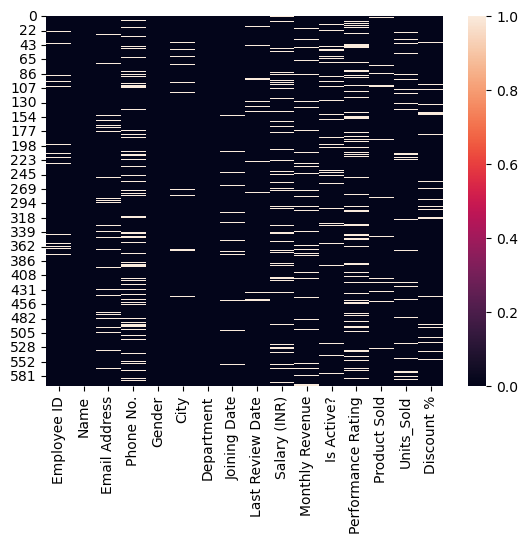

In [376]:
sns.heatmap(df.isnull())

In [377]:
df.describe()

,Joining Date,Last Review Date,Salary (INR),Monthly Revenue,Performance Rating,Units_Sold,Discount %
count,523,519,481.000000,492.000000,457.000000,496.000000,506.000000
mean,2022-02-27 06:17:12.504780032,2022-03-01 06:56:11.098265856,112994.224532,25109.359512,3.028446,246.504032,29.750988
min,2020-01-02 00:00:00,2020-01-02 00:00:00,25111.000000,526.130000,1.000000,0.000000,0.000000
25%,2020-12-16 00:00:00,2021-01-21 12:00:00,71867.000000,12242.110000,2.000000,115.750000,14.000000
50%,2022-02-09 00:00:00,2022-03-09 00:00:00,112374.000000,25038.995000,3.000000,243.500000,29.500000
75%,2023-05-06 12:00:00,2023-03-15 12:00:00,154579.000000,38347.527500,4.000000,377.250000,45.000000
max,2024-07-04 00:00:00,2024-12-03 00:00:00,199808.000000,49948.110000,5.000000,499.000000,60.000000
std,NaN,NaN,49214.785669,14525.581495,1.436240,152.674500,17.683052


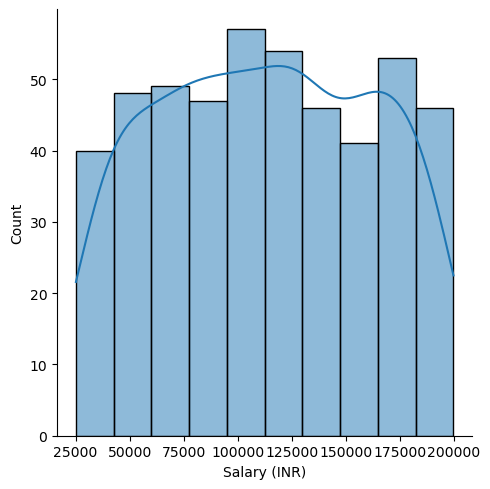

In [378]:
sns.displot(df["Salary (INR)"],kde=True)

<Axes: ylabel='Salary (INR)'>

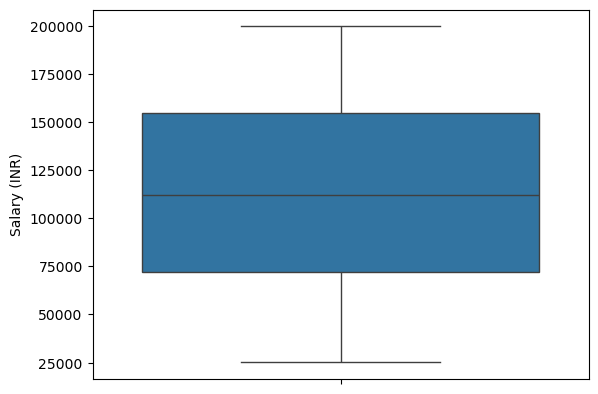

In [379]:
sns.boxplot(df["Salary (INR)"])

In [380]:
df["Salary (INR)"].skew()

np.float64(-0.005988893933331656)

In [381]:
df["Salary (INR)"] = df["Salary (INR)"].fillna(df["Salary (INR)"].mean())

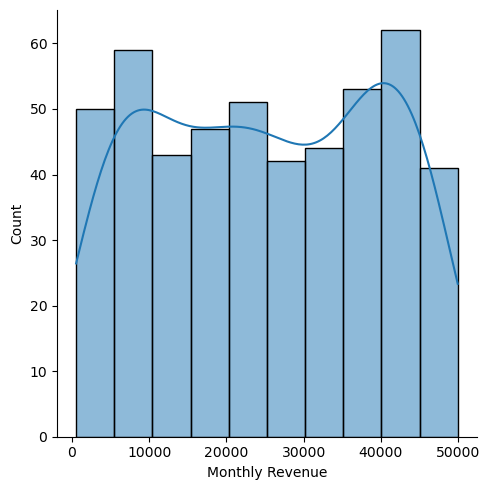

In [382]:
sns.displot(df["Monthly Revenue"],kde=True)

In [383]:
df["Monthly Revenue"].skew()

np.float64(-0.023807584214957503)

In [384]:
df["Monthly Revenue"] = df["Monthly Revenue"].fillna(df["Monthly Revenue"].mean())

<Axes: xlabel='count', ylabel='Is Active?'>

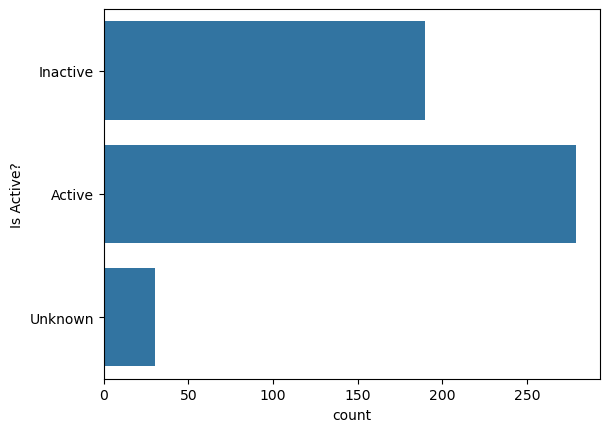

In [385]:
sns.countplot(df["Is Active?"])

In [386]:
df["Is Active?"] = df["Is Active?"].fillna(df["Is Active?"].mode()[0])

In [387]:
df["Is Active?"] = df["Is Active?"].replace("Unknown", pd.NA)

# Step 2 — Fill everything with mode
mode_val = df["Is Active?"].mode()[0]
df["Is Active?"] = df["Is Active?"].fillna(mode_val)

<Axes: ylabel='Performance Rating'>

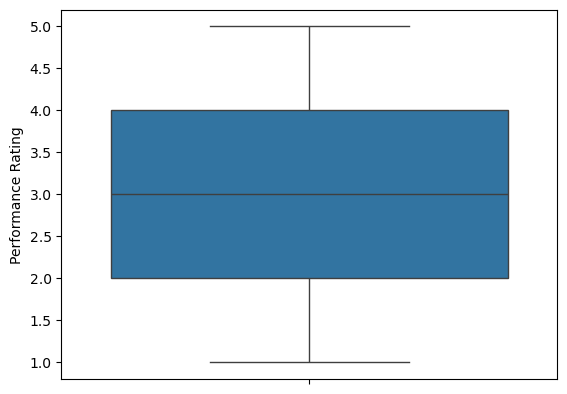

In [388]:
sns.boxplot(df["Performance Rating"])

In [389]:
median_val = round(df["Performance Rating"].median())
df["Performance Rating"] = df["Performance Rating"].fillna(median_val)

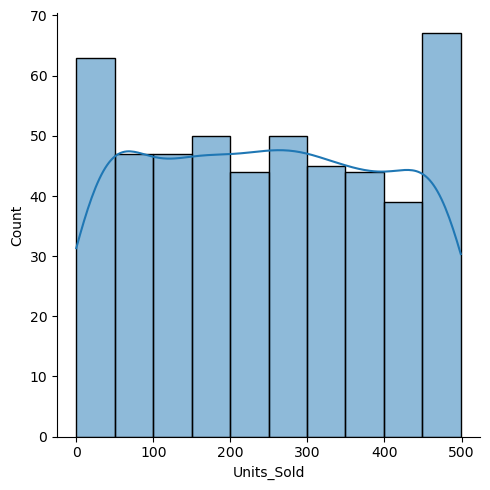

In [390]:
sns.displot(df["Units_Sold"],kde=True)

In [391]:
df["Units_Sold"].skew() 

np.float64(0.02812083070061021)

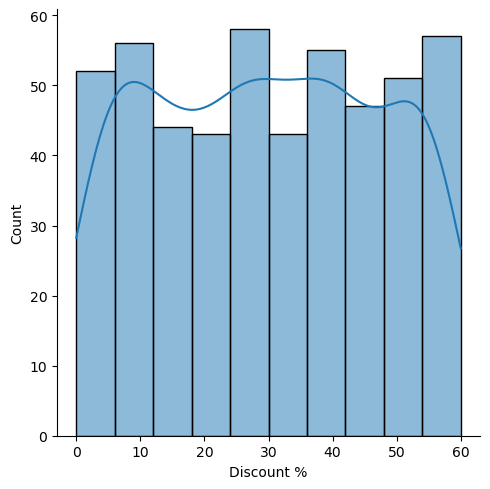

In [392]:
sns.displot(df["Discount %"],kde=True)

In [393]:
cols = ["Discount %","Units_Sold"]
for col in cols:
    mean_val = round(df[col].mean())
    df[col] = df[col].fillna(mean_val)

In [394]:
df["Product Sold"] = df["Product Sold"].fillna(df["Product Sold"].mode()[0])

<Axes: >

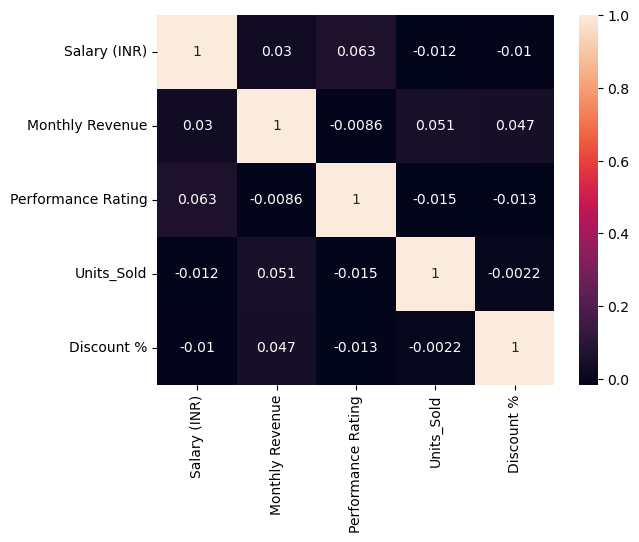

In [395]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [396]:
df.to_csv("employee_cleaned.csv")

In [397]:
dfc = df.copy()

In [398]:
df.columns

Index(['Employee ID', 'Name', 'Email Address', 'Phone No.', 'Gender', 'City',
       'Department', 'Joining Date', 'Last Review Date', 'Salary (INR)',
       'Monthly Revenue', 'Is Active?', 'Performance Rating', 'Product Sold',
       'Units_Sold', 'Discount %'],
      dtype='object')

In [399]:
# empl id , name , email , ph no , jn date , rev date 
df = df.drop(['Employee ID', 'Name', 'Email Address', 'Phone No.','Joining Date', 'Last Review Date'],axis=1)

In [400]:
df.head() 

,Gender,City,Department,Salary (INR),Monthly Revenue,Is Active?,Performance Rating,Product Sold,Units_Sold,Discount %
0,Female,Kolkata,HR,112994.224532,39909.86,Inactive,1.0,Laptop,268.0,30.0
1,Male,Lucknow,Marketing,124655.000000,10691.49,Inactive,3.0,Tablet,237.0,13.0
2,Male,Jaipur,Sales,154478.000000,36779.25,Inactive,4.0,Tablet,46.0,49.0
3,Male,Delhi,Engineering,119182.000000,573.76,Active,5.0,Headphones,381.0,25.0
4,Female,Kolkata,Marketing,144974.000000,35043.19,Active,2.0,Headphones,147.0,21.0


In [401]:
df["Is Active?"] = df["Is Active?"].map({"Active":1 , "Inactive":0})

In [402]:
df = pd.get_dummies(df,columns=['Gender', 'City',
       'Department',  'Product Sold'],drop_first=True,dtype=float)

In [403]:
df.head()

,Salary (INR),Monthly Revenue,Is Active?,Performance Rating,Units_Sold,Discount %,Gender_Male,Gender_Other,Gender_Unknown,City_Bangalore,...,Department_Marketing,Department_Operations,Department_Sales,Product Sold_Headphones,Product Sold_Laptop,Product Sold_Mobile,Product Sold_Monitor,Product Sold_Smartwatch,Product Sold_Speaker,Product Sold_Tablet
0,112994.224532,39909.86,0,1.0,268.0,30.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,124655.000000,10691.49,0,3.0,237.0,13.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,154478.000000,36779.25,0,4.0,46.0,49.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,119182.000000,573.76,1,5.0,381.0,25.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,144974.000000,35043.19,1,2.0,147.0,21.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [406]:
y = df.iloc[:,0]
x = df.iloc[:,2:]

,Is Active?,Performance Rating,Units_Sold,Discount %,Gender_Male,Gender_Other,Gender_Unknown,City_Bangalore,City_Chennai,City_Delhi,...,Department_Marketing,Department_Operations,Department_Sales,Product Sold_Headphones,Product Sold_Laptop,Product Sold_Mobile,Product Sold_Monitor,Product Sold_Smartwatch,Product Sold_Speaker,Product Sold_Tablet
0,0,1.0,268.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0,3.0,237.0,13.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0,4.0,46.0,49.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1,5.0,381.0,25.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,2.0,147.0,21.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
593,1,4.0,243.0,24.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
596,0,5.0,325.0,9.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
597,1,3.0,24.0,56.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
598,1,5.0,452.0,50.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [407]:
x.columns

Index(['Is Active?', 'Performance Rating', 'Units_Sold', 'Discount %',
       'Gender_Male', 'Gender_Other', 'Gender_Unknown', 'City_Bangalore',
       'City_Chennai', 'City_Delhi', 'City_Hyderabad', 'City_Jaipur',
       'City_Kolkata', 'City_Lucknow', 'City_Mumbai', 'City_Pune',
       'City_Unknown', 'Department_Finance', 'Department_HR',
       'Department_Marketing', 'Department_Operations', 'Department_Sales',
       'Product Sold_Headphones', 'Product Sold_Laptop', 'Product Sold_Mobile',
       'Product Sold_Monitor', 'Product Sold_Smartwatch',
       'Product Sold_Speaker', 'Product Sold_Tablet'],
      dtype='object')

In [409]:
from sklearn.preprocessing import StandardScaler

cols_to_scale = ["Units_Sold", "Discount %", "Performance Rating"] 
scaler = StandardScaler()
x[cols_to_scale] = scaler.fit_transform(x[cols_to_scale])

In [410]:
x.head() 

,Is Active?,Performance Rating,Units_Sold,Discount %,Gender_Male,Gender_Other,Gender_Unknown,City_Bangalore,City_Chennai,City_Delhi,...,Department_Marketing,Department_Operations,Department_Sales,Product Sold_Headphones,Product Sold_Laptop,Product Sold_Mobile,Product Sold_Monitor,Product Sold_Smartwatch,Product Sold_Speaker,Product Sold_Tablet
0,0,-1.532173,0.146650,0.013657,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0,-0.018257,-0.065228,-0.979545,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0,0.738701,-1.370673,1.123707,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1,1.495660,0.918981,-0.278461,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,-0.775215,-0.680359,-0.512156,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [411]:
from sklearn.model_selection import train_test_split

x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [412]:
from sklearn.linear_model import LinearRegression 

lr = LinearRegression()

lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [413]:
y_pred = lr.predict(x_test)

In [418]:
from sklearn.metrics import r2_score 
score = r2_score(y_test,y_pred)
score 

-0.08630337128024723

In [420]:
y_pred

array([ 99095.34517519, 103624.28439265,  97638.84119942, 103530.82963744,
       106993.01462076, 143785.65229224, 110751.21690897,  96113.30688131,
       116827.43949501, 115898.57025858, 119288.18818953, 111668.20948315,
       114554.59053502,  94871.90119631, 133750.1951551 , 119453.31147593,
        98430.3903412 , 132563.01979073, 101651.30642533, 114011.64866164,
       123243.7132002 , 117074.43786541, 114981.62593321, 110302.28925689,
        94662.59217421, 130349.41622221, 104986.28348484, 107658.37289017,
       114075.7882976 , 116864.4183413 , 134479.10673365, 113865.23943188,
       123368.18491896, 108796.4499791 , 113933.11045567, 101299.71813177,
       116185.40642676, 122404.52952742,  99881.41657414, 114268.06661459,
       131332.97115075,  97471.28729423, 132959.78992257,  90055.82041698,
       121508.56963923, 121032.06122279, 105444.40871672, 136566.77034611,
       112716.18780595, 103599.4637749 , 116711.80181505, 116852.34877129,
        98588.42531666, 1

In [421]:
y_test

531     47186.0
75     122099.0
376    184233.0
88      82826.0
500     68747.0
         ...   
425     71777.0
32     195559.0
115    152382.0
185     45288.0
540    169681.0
Name: Salary (INR), Length: 162, dtype: float64